# SpatialProp LOO Evaluation

Mirrors `perturb_loo.ipynb` but uses the spatial-prop GNN instead of cellina.

**Experiment logic:**
- Hold out `holdout_celltype` cells from the CRC region during GNN training
- At inference, the GNN predicts those cells' expression from their *actual* CRC neighbors
- This CRC-neighbor prediction is the analog of cellina's spatial-context swap
- We measure how well the predicted CRC expression matches the real holdout cells using `compute_cf_logfc`

**Metrics (same as perturb_loo.ipynb):**
- `ref_expr` = GNN prediction for holdout cells *in REF* (from REF neighbors)
- `pert_expr` = GNN prediction for holdout cells *in CRC* (from CRC neighbors) ← the "perturbation"
- `cf_expr`  = real expression for holdout cells in CRC ← ground truth

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import os
import sys
sys.path.append('../../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import pearsonr

from spatial_gnn.api.perturbation_api import (
    train_perturbation_model,
    create_perturbation_input_matrix,
    predict_perturbation_effects
)
from spatial_gnn.utils.plot_utils import (
    plot_loss_curves,
    plot_celltype_performance,
    plot_celltypes_in_section,
    plot_propagation_results_for_gene_set
)

from perturb_utils import load_crc_slide, split_indices, compute_cf_logfc

plt.rcParams['figure.dpi'] = 100

/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/libpyg.so: undefined symbol: _ZN5torch8autograd12VariableInfoC1ERKN2at6TensorE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred whi

In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id         = 242
labels_key       = 'coarse_type'
domains_key      = 'typ'
holdout_celltype = 'T_cell'   # change to 'Fibroblast', 'Myeloid', etc.
top_n            = 100        # genes for logFC metric evaluation
exp_name         = f'crc_loo_{holdout_celltype}'
out_dir          = f'./output/{exp_name}'

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'
top_n_perturb    = 100

In [3]:
import inspect

In [4]:
import anndata as ad
from typing import Dict, Optional
from scipy.sparse import issparse

def create_perturbation_input_matrix(
    adata: ad.AnnData,
    perturbation_dict: Dict[str, Dict[str, float]],
    mask_key: str = 'perturbed_input',
    save_path: Optional[str] = None,
    normalize_total: bool = True,
    operation: str = 'multiply',
) -> str:
    """
    Store a full perturbed expression matrix in adata.obsm[mask_key] with the same
    normalization as the training data.

    Parameters
    ----------
    operation : {'multiply', 'add'}, default 'multiply'
        How to apply each perturbation value to the existing expression:
        - 'multiply': perturbed = expression * value
        - 'add':      perturbed = expression + value
    """
    if operation not in ('multiply', 'add'):
        raise ValueError(
            f"operation must be 'multiply' or 'add', got '{operation}'"
        )

    perturbed_adata = adata.copy()

    X = perturbed_adata.X
    if issparse(X):
        X = X.toarray()
    else:
        X = np.asarray(X)

    perturbed = X.copy()  # start from normalized expression

    for cell_type, gene_values in perturbation_dict.items():
        cell_mask = perturbed_adata.obs['celltype'] == cell_type
        cell_indices = np.where(cell_mask)[0]

        if len(cell_indices) == 0:
            print(f"Warning: No cells found for cell type '{cell_type}'")
            continue

        print(f"Applying perturbations to {len(cell_indices)} cells of type '{cell_type}'")

        for gene_name, value in gene_values.items():
            if gene_name in perturbed_adata.var_names:
                gene_idx = perturbed_adata.var_names.get_loc(gene_name)

                if operation == 'multiply':
                    perturbed[cell_indices, gene_idx] *= value
                    print(f"  - Gene '{gene_name}': multiplier = {value}")
                else:  # 'add'
                    perturbed[cell_indices, gene_idx] += value
                    # clip negatives that can arise from additive perturbation
                    np.clip(
                        perturbed[cell_indices, gene_idx],
                        a_min=0,
                        a_max=None,
                        out=perturbed[cell_indices, gene_idx],
                    )
                    print(f"  - Gene '{gene_name}': addend = {value}")
            else:
                print(f"Warning: Gene '{gene_name}' not found in data")

    if normalize_total:
        target_sum = X.shape[1]
        row_sums = perturbed.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # avoid /0
        perturbed = perturbed / row_sums * target_sum
        perturbed_adata.obsm[mask_key] = perturbed

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        perturbed_adata.write(save_path)
        print(f"Saved AnnData with perturbation input to: {save_path}")

    return save_path


## 1. Data Loading & Column Mapping

spatial-prop requires `obs["celltype"]`, `obs["mouse_id"]`, and optionally `obs["region"]`.

In [5]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)

adata.obs['celltype'] = adata.obs[labels_key]
adata.obs['mouse_id'] = str(slide_id)
adata.obs['region']   = adata.obs[domains_key]

print(adata)
print(f"\nCell types: {sorted(adata.obs['celltype'].unique())}")
print(f"Regions:    {sorted(adata.obs['region'].unique())}")

AnnData object with n_obs × n_vars = 420694 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [6]:
adata.X.max()
np.exp(1.5), np.exp(-0.5)

(np.float64(4.4816890703380645), np.float64(0.6065306597126334))

> **Caveat — coordinate units**: `obsm['spatial']` contains CosMx global pixel coordinates
> (~0.12 µm/px). spatial-prop's Delaunay graph pruning uses a radius cutoff hardcoded at
> 200 in `spatial_dataset.py`. If that unit is µm, 200 µm ÷ 0.12 µm/px ≈ 1667 px — meaning
> the cutoff of 200 would include only cells within ~24 µm, which may be too tight.
> Check whether `train_perturbation_model` accepts a `radius_cutoff` kwarg and set it
> accordingly (e.g. `"radius_cutoff": 1667`).

## 2. Holdout Split → adata_train / adata_test

In [7]:
train_idx, val_idx, test_idx = split_indices(
    adata, holdout_celltype=holdout_celltype,
    labels_key=labels_key, domains_key=domains_key,
)
# adata.obs['is_holdout'] is now True for holdout_celltype cells in any CRC region

print(f"train: {len(train_idx):,}  val: {len(val_idx):,}  holdout (CRC): {len(test_idx):,}")
print(f"Held-out cells: {adata.obs['is_holdout'].sum()} {holdout_celltype} in CRC region")

adata_train = adata[~adata.obs['is_holdout']].copy()   # holdout CRC cells excluded
adata_test  = adata.copy()                              # full slide for inference

os.makedirs(out_dir, exist_ok=True)
train_path = f'{out_dir}/adata_train.h5ad'
test_path  = f'{out_dir}/adata_test.h5ad'
adata_train.write(train_path)
adata_test.write(test_path)

print(f"\nSaved: {train_path}")
print(f"Saved: {test_path}")

train: 375,705  val: 41,744  holdout (CRC): 3,245
Held-out cells: 3245 T_cell in CRC region

Saved: ./output/crc_loo_T_cell/adata_train.h5ad
Saved: ./output/crc_loo_T_cell/adata_test.h5ad


## 3. Train SpatialProp GNN

> **Caveat — in-sample test loss**: `train_ids == test_ids` (single slide). The test loss
> reported during training reflects in-sample fit, not generalisation to the holdout cells.
> Real validation happens in Section 4 below.

In [8]:
training_args = {
    'dataset':             f'crc_{slide_id}_{holdout_celltype}',
    'file_path':           train_path,
    'train_ids':           [str(slide_id)],
    'test_ids':            [str(slide_id)],   # same — in-sample only
    'exp_name':            exp_name,
    'k_hop':               2,
    'augment_hop':         2,
    'center_celltypes':    'all',
    'node_feature':        'expression',
    'inject_feature':      'none',
    'learning_rate':       1e-3,
    'loss':                'weightedl1',
    'epochs':              30,
    'normalize_total':     True,
    'num_cells_per_ct_id': 100,
    'predict_celltype':    False,
    'pool':                'center',
    'do_eval':             False,
    'device':              'cuda' if torch.cuda.is_available() else 'cpu',
    # Uncomment and set if train_perturbation_model accepts radius_cutoff:
    # 'radius_cutoff': 1667,   # ~200 µm at 0.12 µm/px
}

test_loader, gene_names, (model, model_config, trained_model_path) = \
    train_perturbation_model(**training_args)

print(f"\nModel saved to: {trained_model_path}")

Training new perturbation model from scratch...
Model will be saved to: ./output/crc_loo_T_cell/crc_242_T_cell_expression_2hop_2augment_expression_none/weightedl1_1en03
Training on device: cuda
Dataset already exists at:  ./data/gnn_datasets/crc_242_T_cell_expression_100per_2hop_2C0aug_200delaunay_expressionFeat_all_NoneInject_subset_242/test
Finished processing test dataset
Dataset already exists at:  ./data/gnn_datasets/crc_242_T_cell_expression_100per_2hop_2C0aug_200delaunay_expressionFeat_all_NoneInject_subset_242/train
Finished processing train dataset


100%|██████████| 34/34 [00:04<00:00,  7.61it/s]
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
100%|██████████| 34/34 [00:04<00:00,  7.90it/s]

Train samples: 16746
Test samples: 16746


Expression model initialized on cuda
Starting GNN training for 30 epochs...
 Epoch: 001, Train WL1: 10.0114, Test WL1: 10.0114, Test Spearman: 0.0768
 Epoch: 002, Train WL1: 9.8151, Test WL1: 9.8168, Test Spearman: 0.1141
 Epoch: 003, Train WL1: 9.4517, Test WL1: 9.4543, Test Spearman: 0.1187
 Epoch: 004, Train WL1: 9.4070, Test WL1: 9.4092, Test Spearman: 0.1199
 Epoch: 005, Train WL1: 9.3756, Test WL1: 9.3773, Test Spearman: 0.1218
 Epoch: 006, Train WL1: 9.3070, Test WL1: 9.3093, Test Spearman: 0.1252
 Epoch: 007, Train WL1: 9.2432, Test WL1: 9.2453, Test Spearman: 0.1273
 Epoch: 008, Train WL1: 9.1981, Test WL1: 9.2000, Test Spearman: 0.1271
 Epoch: 009, Train WL1: 9.1545, Test WL1: 9.1570, Test Spearman: 0.1281
 Epoch: 010, Train WL1: 9.1153, Test WL1: 9.1183, Test Spearman: 0.1283
 Epoch: 011, Train WL1: 9.1002, Test WL1: 9.1032, Test Spearman: 0.1271
 Epoch: 012, Train WL1: 9.0773, Test WL1: 9.0803, Test Spearman: 0.1254
 Epoch: 013, Train WL1: 9.0610, Test WL1: 9.0628, Test Spe

In [9]:
import scanpy as sc
from spatial_gnn.datasets.spatial_dataset import SpatialAgingCellDataset
from spatial_gnn.utils.dataset_utils import load_model_from_path, create_dataloader_from_dataset
from spatial_gnn.models.inference import predict


def predict_for_holdout(adata_path, model_path, exp_name,
                        center_celltypes, use_ids=None,
                        device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Like predict_perturbation_effects but restricts center nodes to
    center_celltypes (instead of whole_tissue=True which uses all 420k cells).

    Neighbourhoods in the Delaunay graph still include ALL cell types, so
    context is preserved. Only the set of cells that generate a prediction
    subgraph is reduced — from 420k (all cells) to ~30k (holdout type only).

    whole_tissue=False  + num_cells_per_ct_id=100_000 routes through the
    per-cell-type sampling branch in _process_single_sample, selecting
    min(100_000, n_cells_of_type) ≈ all cells of that type.
    """
    test_adata = sc.read_h5ad(adata_path)
    model, model_config = load_model_from_path(model_path, device)
    celltypes_to_index = model_config['celltypes_to_index']

    shared_kwargs = dict(
        subfolder_name='predict_holdout',
        dataset_prefix=exp_name,
        target='expression',
        k_hop=2,
        augment_hop=0,            # no augmentation at inference
        node_feature='expression',
        inject_feature=None,
        num_cells_per_ct_id=100_000,   # effectively "all" for the selected type
        center_celltypes=center_celltypes,
        whole_tissue=False,       # must be False for center_celltypes to be respected
        use_ids=use_ids,
        raw_filepaths=[adata_path],
        celltypes_to_index=celltypes_to_index,
        normalize_total=True,
    )

    test_dataset = SpatialAgingCellDataset(**shared_kwargs)
    test_dataset.process()

    perturbed_test_dataset = SpatialAgingCellDataset(
        **shared_kwargs,
        perturbation_mask_key='perturbed_input',
        use_perturbed_expression=True,
    )
    perturbed_test_dataset.process()

    loader_kwargs = dict(batch_size=512, shuffle=False, num_workers=4,
                         pin_memory=True, persistent_workers=True)
    _, test_loader = create_dataloader_from_dataset(test_dataset, **loader_kwargs)
    _, pert_loader = create_dataloader_from_dataset(perturbed_test_dataset, **loader_kwargs)

    return predict(
        model=model, adata=test_adata,
        dataloader=test_loader, perturbed_dataloader=pert_loader,
        use_ids=use_ids, temper_method='distribution_renormalize', device=device,
    )

We can also plot performance of the model by cell type on the held-out mouse. Here we show correlation metrics for the masked center cell expression prediction task used during training.

In [10]:
# plot_celltype_performance(model_dir)

In [11]:
import decoupler as dc
import scanpy as sc

pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col=domains_key,
    groups_col=labels_key,
    mode='sum',
    layer='counts',
)
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'

cell_types = [
    ct for ct in pdata.obs[labels_key].unique()
    if ((pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)).any()
    and ((pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)).any()
]

domain_logfc_df = pd.concat(
    [
        pd.Series(
            (
                pdata[(pdata.obs[domains_key] == crc_label) & (pdata.obs[labels_key] == ct)].X
                - pdata[(pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)].X
            ).flatten(),
            index=pdata.var_names,
            name=ct,
        )
        for ct in cell_types
    ],
    axis=1,
).T

print(f"logFC matrix: {domain_logfc_df.shape}  (cell types × genes)")
domain_logfc_df.head()

logFC matrix: (8, 3000)  (cell types × genes)


,DDX60L,SH3TC1,RGS7,STAP1,G0S2,PTPRR,ATP13A4,ROS1,MSX2,PSMG4,...,GPR15,ARHGEF4,FAM163A,ACTRT3,RCAN1,PIM1,LAPTM5,APOL1,CXCL5,H3C12
Endothelial,-0.577904,-0.356066,-0.529708,-0.274982,0.112245,-0.754418,-0.121465,-0.359818,-0.625385,-0.023726,...,-0.320390,-0.317067,-0.267649,-0.528553,-0.154368,0.049475,0.689768,-0.026805,-0.527561,0.078071
Epithelial,-0.413618,-0.015889,-0.234075,-0.228569,-0.067379,0.430408,-0.418969,-0.527748,-0.111391,0.041345,...,-0.241690,-0.210079,-0.208957,-0.338790,-0.301606,0.146697,-0.182228,0.670551,-0.441461,0.311994
Fibroblast,-0.453132,-0.337090,-0.372903,-0.400685,-0.452654,-0.387643,-0.275183,-0.488787,-0.477614,-0.471474,...,-0.684369,-0.410710,-0.529076,-0.636689,-0.362732,0.255989,0.433973,0.232396,-0.300495,-0.224854
Mast_cell,-0.266114,0.755196,0.020974,-0.769114,-0.307306,-0.154589,0.081252,-0.778805,-0.554431,-0.162174,...,-0.098884,-0.295956,-0.130437,-0.079095,-0.136951,0.642027,1.396774,0.113619,-0.400048,-0.341742
Myeloid,-0.123918,-0.265512,-0.187573,-0.414656,-0.213312,-0.321049,-0.069781,-0.511003,-0.421269,-0.557012,...,-0.323155,-0.156370,-0.456663,-0.120254,0.016705,0.205870,0.573811,0.080854,0.067158,-0.016721


In [12]:

perturbation_dict = {}
for ct in domain_logfc_df.index:
    s = domain_logfc_df.loc[ct]
    top_genes = s.abs().nlargest(top_n_perturb).index.tolist()
    # perturbation_dict[ct] = np.exp(s[top_genes]).to_dict()
    perturbation_dict[ct] = s[top_genes].to_dict()

In [13]:
perturbed_path = f'{out_dir}/adata_test_perturbed.h5ad'
create_perturbation_input_matrix(
    adata_test, perturbation_dict,
    save_path=perturbed_path,
    normalize_total=True,
    operation='add',
)

adata_result = predict_for_holdout(
    perturbed_path,
    trained_model_path,
    exp_name,
    center_celltypes=[holdout_celltype],
    use_ids=[str(slide_id)],
)

print('Layers available:', list(adata_result.layers.keys()))
print('Result shape:', adata_result.shape)

Applying perturbations to 7506 cells of type 'Endothelial'
  - Gene 'CLU': addend = -2.2809000347552573
  - Gene 'COL4A1': addend = 2.0675633399610573
  - Gene 'IGFBP3': addend = 2.0550703562322634
  - Gene 'ACKR1': addend = -1.9763310983312452
  - Gene 'COL1A1': addend = 1.9216237448767912
  - Gene 'SPARC': addend = 1.8214454156884043
  - Gene 'IGHA1': addend = -1.788989530925425
  - Gene 'FOS': addend = -1.7616611957583075
  - Gene 'COL4A2': addend = 1.667985552531786
  - Gene 'NID1': addend = 1.6354716895150314
  - Gene 'FN1': addend = 1.6039986534070803
  - Gene 'CALD1': addend = 1.5631631174148248
  - Gene 'MMP2': addend = 1.5567346430488316
  - Gene 'COL1A2': addend = 1.5509812781512209
  - Gene 'ESM1': addend = 1.5394672921268093
  - Gene 'FSTL1': addend = 1.5379758610664505
  - Gene 'H3C2': addend = 1.5125223925878166
  - Gene 'IGFBP5': addend = 1.4841588316713943
  - Gene 'OLFM4': addend = -1.434195771518747
  - Gene 'THBS1': addend = 1.4317007457413897
  - Gene 'HSPG2': adden

100%|██████████| 36/36 [00:03<00:00, 10.67it/s]
/data/ddimitrov/software/miniforge3/envs/spprop/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
100%|██████████| 36/36 [00:03<00:00, 10.04it/s]


Starting prediction for 420694 cells, 3000 genes


Predicting (unperturbed & perturbed) with tempering...:   0%|          | 0/35 [00:00<?, ?it/s]/data/ddimitrov/repos/cellina-reproducibility/spatial-prop/src/spatial_gnn/models/inference.py:123: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_expn_batch = torch.tensor(
Predicting (unperturbed & perturbed) with tempering...: 100%|██████████| 35/35 [00:02<00:00, 12.80it/s]
/data/ddimitrov/repos/cellina-reproducibility/spatial-prop/src/spatial_gnn/models/inference.py:150: ImplicitModificationWarning: Setting element `.layers['predicted_unperturbed']` of view, initializing view as actual.
  adata.layers["predicted_unperturbed"] = unperturbed_prediction_matrix


Predicted on 17908 cells
Applied tempering with method 'distribution_renormalize' (batch-wise)
Layers available: ['counts', 'predicted_unperturbed', 'predicted_perturbed', 'predicted_tempered']
Result shape: (420694, 3000)


## 5. logFC Metrics — Mirroring perturb_loo.ipynb`

In [14]:
mask_holdout_crc = (
    (adata_result.obs['celltype'] == holdout_celltype) &
    (adata_result.obs['region']   == crc_label)
)
mask_holdout_ref = (
    (adata_result.obs['celltype'] == holdout_celltype) &
    (adata_result.obs['region']   == ref_label)
)


In [15]:
def _total_normalize(X):
    X = X.toarray() if hasattr(X, 'toarray') else np.asarray(X, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X = np.clip(X, 0, None)
    X = X / np.maximum(X.sum(axis=1, keepdims=True), 1e-6)
    X = X * 1e4
    return X

    
# ref_expr  = _total_normalize(np.expm1(adata_result[mask_holdout_ref].layers['predicted_unperturbed']))
ref_expr = _total_normalize(adata_result[mask_holdout_ref].X)
# NOTE: we use perturbed and not tempered here, because the latter requires observing the data and we want to avoid any data leakage in this holdout setting (fair for other methods too, since they also can't use the observed data in the holdout CRC cells)
pert_expr  = _total_normalize(adata_result[mask_holdout_crc].layers['predicted_perturbed'])
obs_expr = _total_normalize(adata_result[mask_holdout_crc].X)


ref_expr = ref_expr.toarray() if hasattr(ref_expr, 'toarray') else ref_expr
pert_expr = pert_expr.toarray() if hasattr(pert_expr, 'toarray') else pert_expr
obs_expr = obs_expr.toarray() if hasattr(obs_expr, 'toarray') else obs_expr

stats = compute_cf_logfc(
    ref_expr=ref_expr, pert_expr=pert_expr, obs_expr=obs_expr,
    top_n=top_n,
    gene_names=adata_result.var_names.tolist(),
)

print(f"Pearson r  = {stats['pearson_r']:.3f}")
print(f"Spearman ρ = {stats['spearman_r']:.3f}")
print(f"Precision  = {stats['precision']:.2f}")
print(f"Edistance  = {stats['edistance']:.3f}")

Pearson r  = 0.714
Spearman ρ = 0.641
Precision  = 0.26
Edistance  = 547.513


In [16]:
# Pearson r  = 0.669
# Spearman ρ = 0.523
# Precision  = 0.33
# Edistance  = 655.757

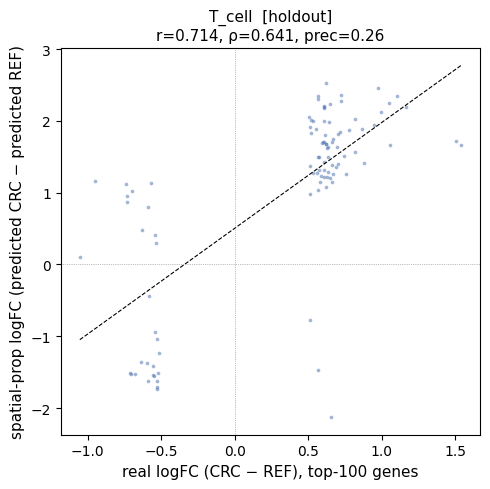

In [17]:
real = stats['real_logfc']
pred = stats['pred_logfc']
mask = stats['top_n_mask']
if mask is not None:
    real, pred = real[mask], pred[mask]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(real, pred, s=3, alpha=0.4, color='#4C72B0')

m, b = np.polyfit(real, pred, 1)
x_lo, x_hi = real.min(), real.max()
ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], 'k--', lw=0.8)
ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.axvline(0, color='grey', lw=0.5, ls=':')

ax.set_xlabel(f'real logFC (CRC − REF), top-{top_n} genes', fontsize=11)
ax.set_ylabel('spatial-prop logFC (predicted CRC − predicted REF)', fontsize=11)
ax.set_title(
    f"{holdout_celltype}  [holdout]\n"
    f"r={stats['pearson_r']:.3f}, ρ={stats['spearman_r']:.3f}, prec={stats['precision']:.2f}",
    fontsize=11,
)

plt.tight_layout()
plt.show()